## ДЗ №2. Матричные факторизации

#### В этой домашке вам предстоит реализовать некоторые базовые модели матричной факторизации

#### Дата выдачи: 17.02.25

#### Мягкий дедлайн: 02.03.25 23:59 MSK

#### Жесткий дедлайн: 09.03.25 23:59 MSK

В этом задании мы будем работать с классическим для рекоендательных систем датасетом [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/). Датасет содержит рейтинги оценки для 4000 фильмов от 6000 пользователей. Более подробное описание можете найти на странице с датасетом и в README файле

In [1]:
!wget https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip ml-1m.zip
!cat ml-1m/README

--2025-03-05 21:39:12--  https://files.grouplens.org/datasets/movielens/ml-1m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.65.152
Connecting to files.grouplens.org (files.grouplens.org)|128.101.65.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5917549 (5.6M) [application/zip]
Saving to: ‘ml-1m.zip’

ml-1m.zip           100%[===================>]   5.64M  24.1KB/s    in 2m 47s  

2025-03-05 21:42:01 (34.7 KB/s) - ‘ml-1m.zip’ saved [5917549/5917549]

Archive:  ml-1m.zip
   creating: ml-1m/
  inflating: ml-1m/movies.dat        
  inflating: ml-1m/ratings.dat       
  inflating: ml-1m/README            
  inflating: ml-1m/users.dat         
SUMMARY

These files contain 1,000,209 anonymous ratings of approximately 3,900 movies 
made by 6,040 MovieLens users who joined MovieLens in 2000.

USAGE LICENSE

Neither the University of Minnesota nor any of the researchers
involved can guarantee the correctness of the data, its suitability
for any

In [117]:
import pandas as pd
import numpy as np
from typing import Union

In [118]:
df = pd.read_csv("ml-1m/ratings.dat", sep='::', names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df.drop('timestamp', axis=1, inplace=True)
df.head()

,user_id,item_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [119]:
value_counts = df['item_id'].value_counts()
filtered_values = value_counts[value_counts > 20].index
df = df[df['item_id'].isin(filtered_values)].copy()

In [120]:
train_end = '2000-12-01'
df_train = df[df['datetime'] < train_end].copy()
df_test = df[df['datetime'] >= train_end].copy()
df_train.shape, df_test.shape

((787420, 4), (207432, 4))

In [121]:
train_users = df_train['user_id'].unique()
train_items = df_train['item_id'].unique()

df_test = df_test[df_test['user_id'].isin(train_users)]
df_test = df_test[df_test['item_id'].isin(train_items)]
df_test.shape

(106471, 4)

In [122]:
from sklearn.preprocessing import LabelEncoder

user_le = LabelEncoder()
item_le = LabelEncoder()

df_train['user_id'] = user_le.fit_transform(df_train['user_id'])
df_train['item_id'] = item_le.fit_transform(df_train['item_id'])

df_test['user_id'] = user_le.transform(df_test['user_id'])
df_test['item_id'] = item_le.transform(df_test['item_id'])

In [123]:
df_train['user_id'].nunique(), df_train['user_id'].max()
df_train['item_id'].nunique(), df_train['item_id'].max()

(3010, 3009)

In [132]:
unique_users = df_train['user_id'].unique()
unique_items = df_train['item_id'].unique()

max_user_id = unique_users.max()
max_item_id = unique_items.max()

##### Задание 1. Напишем функцию, которая превратит датафрейм в матрицу интеракций. В функции df_to_matrix реализуйте функцию, которая принимает датафрейм и возвращает np.array матрицу интеракций. В функции df_to_coo реализуйте функцию, которая принимает датафрейм и возвращает разреженную матрицу интеракций в coo_array формате

In [133]:
def df_to_matrix(df: pd.DataFrame) -> np.ndarray:
    matrix = np.zeros((max_user_id + 1, max_item_id + 1))
    
    for _, row in df.iterrows():
        user_idx = row['user_id']
        item_idx = row['item_id']
        rating = row['rating']
        matrix[user_idx, item_idx] = rating

    return matrix

In [134]:
interractions = df_to_matrix(df_train)

In [135]:
from scipy.sparse import coo_array

def df_to_coo(df: pd.DataFrame) -> coo_array:
    rows = [row['user_id'] for _, row in df.iterrows()]
    cols = [row['item_id'] for _, row in df.iterrows()]
    data = df['rating'].values
    
    result = coo_array((data, (rows, cols)), shape=(max_user_id + 1, max_item_id + 1))

    return result

In [136]:
coo_interactions = df_to_coo(df_train)

In [137]:
assert (interractions != 0).sum() == df_train.shape[0]
assert interractions[0, 2994] == 3
assert interractions[2369, 1203] == 5
assert interractions[1557, 459] == 3
assert np.allclose(coo_interactions.toarray(), interractions)

##### Задание 2.1. Рассмотрим [SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition). Возьмите готовую реализуцию алгоритма из numpy.linalg или из scipy.linalg и примените алгоритм к матрицам интеракций, полученным в первом задании. Для работы со sparse матрицей обычная реализация svd не подойдет и нужно будет воспользоваться scipy.sparse.linalg.svds. Вам нужно разложить матрицу интеракций на 3 матрицы U, S, V, а затем перемножить их и восстановить изначальную матрицу. При полном разложении исходная матрица должна восстанавливаться максимально хорошо

In [139]:
from scipy.sparse.linalg import svds

def make_svd(interractions: Union[np.ndarray, coo_array], n_singular_values: int = -1):
    # функция должна работать и для полной матрицы и для sparse матрицы(вам поможет isinstance).
    # если n_singular_values = -1, то берем все сингулярные числа для полной матрицы
    # и все кроме одного сингулярного числа для coo-матрицы(иначе scipy.sparse.linalg.svds не будет работать)
    if isinstance(interractions, coo_array):
        U, S, V = svds(interractions.tocsr(), k=n_singular_values)
        idx = S.argsort()[::-1]
        U = U[:, idx]
        S = S[idx]
        V = V[idx, :]
    else:
        U, S, V = np.linalg.svd(interractions, full_matrices=False)
        if n_singular_values > 0:
            U = U[:, :n_singular_values]
            S = S[:n_singular_values]
            V = V[:n_singular_values, :]
    
    return U, S, V

In [140]:
U, S, V = make_svd(interractions)
assert np.allclose(U @ np.diag(S) @ V, interractions)

In [141]:
U1, S1, V1 = make_svd(interractions, 10)
U, S, V = make_svd(coo_interactions, 10)
assert np.allclose(U1 @ np.diag(S1) @ V1, U @ np.diag(S) @ V)

##### Задание 2.2. Теперь попробуем сделать рекомендации с помощью SVD. Мы научились восстанавливать исходную матрицу с помощью разложения, теперь же мы хотим порекомендовать пользователю айтемы, которые будут для него максимально релевантны(в восстановленной матрице у них будет самый высокий скор). Для каждого пользователя нужно будет найти индексы айтемов, которые имеют максимальный скор. При этом стоит обратить внимание, что мы не хотим рекомендовать пользователю айтемы, с которыми он уже взаимодействовал

In [142]:
def make_svd_recommendations(interractions: Union[np.ndarray, coo_array], n_singular_values: int = -1, top_k: int = 100) -> np.array:
    # Возвращает матрицу вида n_users, top_k, то есть для каждого пользователя возвращаем индексы 
    # top_k самых релевантный айтемов среди тех с которыми он еще не взаимодействовал

    U, S, V = make_svd(interractions, n_singular_values)
    m_recovered = U @ np.diag(S) @ V

    # получаем id всех элементов
    all_items = set(range(interractions.shape[1]))

    recommendations = []
    for i, pred_values in enumerate(m_recovered):
        # Получаем все элементы, с которыми пользователь взаимодействовал.
        if isinstance(interractions, coo_array):
            user_interractions = set(interractions.col[interractions.row == i])
        else:
            user_interractions = set(np.nonzero(interractions[i])[0])
        # Собираем только те элементы, с которыми пользователь не взаимодействовал.
        not_inerracted_items = all_items - user_interractions
        # Сортируем рекомендованные пользователю элементы и добавляем в ответ.
        recommended_item_indices = sorted(not_inerracted_items, key=lambda idx: pred_values[idx], reverse=True)
        recommendations.append(recommended_item_indices[:top_k])

    return np.array(recommendations) #shape ~ [n_users, top_k]

In [143]:
recs = make_svd_recommendations(interractions, -1, 100)
assert recs.shape == (interractions.shape[0], 100)

##### Задание 2.3. Теперь давайте посмотрим как будет зависеть качетво рекомендаций, от количества сингулярных чисел, которые мы возьмем в SVD разложении. Переберите n_singular_values из списка [1, 10, 50, 200, 1000] и посмотрите как будет изменяться метрика NDCG на тестовом датасете для таких рекомендаций и как будет меняться время вычисления. Для каждого графики зависимости метрики NDCG от n_singular_values и времени работы алгоритма от n_singular_values(Время работы будет меняться только для sparse-матрицы, стоит запускать алгоритм именно для нее)

In [144]:
test2 = df_test.sort_values(by=['user_id', 'datetime'])
real_items_oreder = test2.groupby('user_id')['item_id'].apply(list)

In [145]:
real_items_oreder[0]

[925, 927, 670, 1979, 2251, 926, 2992, 936, 3004, 959, 1242]

In [146]:
recs[0]

array([   7,   13,    4,   30, 1704, 3008, 2515,  565, 1341,  564, 1946,
       2973,  483, 2771,    0, 1696, 2883, 1988, 2966,  780, 1917, 2991,
       2962,  833, 2296, 2825, 2375, 1274, 1741,  178, 3000, 2984,  481,
        479, 2993, 3007,  862, 2953, 2915, 2979,  233, 2708, 1373, 2678,
       2967, 2583, 2889, 1871, 2846, 1077, 2682, 2026, 2262, 2707, 2339,
       2963, 2181, 2735, 2091,  536,  113,   26,  474, 1133, 1183, 1537,
       1822, 1320, 2458, 1870, 1591, 1955, 1987, 1794, 2999, 1854, 1647,
       1362, 2450, 1505,  480, 2016, 2516,  796, 3003, 2619, 2499, 1140,
       1107, 2726, 2039, 1260, 2958, 3002, 2642, 1122, 2998, 2102, 1277,
       2533])

In [148]:
from time import time
import matplotlib.pyplot as plt

def dcg(scores):
    return np.sum(
        np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)), dtype=np.float64
    )

def ndcg_metric(gt_items, predicted):
    at = len(predicted)
    # relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    relevance = np.isin(gt_items, predicted).astype(int)
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_

def plot_graphs(interractions: Union[np.ndarray, coo_array], test_recs, top_k: int = 100):
    metrics = []
    timings = []
    n_singular_values_list = [1, 10, 50, 200, 1000]
    for n_singular_values in n_singular_values_list:
        start_time = time()
        recs = make_svd_recommendations(interractions, n_singular_values, top_k)
        elapsed_time = time() - start_time
        timings.append(elapsed_time)
        metric_values = []
        for idx, predictions in enumerate(recs):
            real_values = test_recs.get(idx, [])
            metric_values.append(ndcg_metric(real_values, predictions))
        metrics.append(np.mean(metric_values))
    
    plt.figure(figsize=(10, 5))
    plt.plot(n_singular_values_list, metrics, marker='o')
    plt.title("Зависимость NDCG@k от n_singular_values")
    plt.xlabel("n_singular_values")
    plt.ylabel("Avg NDCG@k")
    plt.grid()
    plt.show()
    
    # График времени
    plt.figure(figsize=(10, 5))
    plt.plot(n_singular_values_list, timings, marker='o', color='orange')
    plt.title("Зависимость времени работы от n_singular_values")
    plt.xlabel("n_singular_values")
    plt.ylabel("Время (с)")
    plt.grid()
    plt.show()

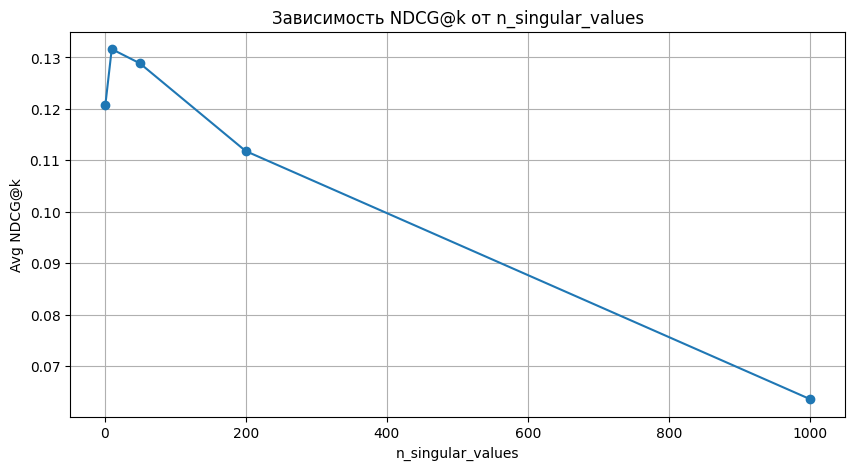

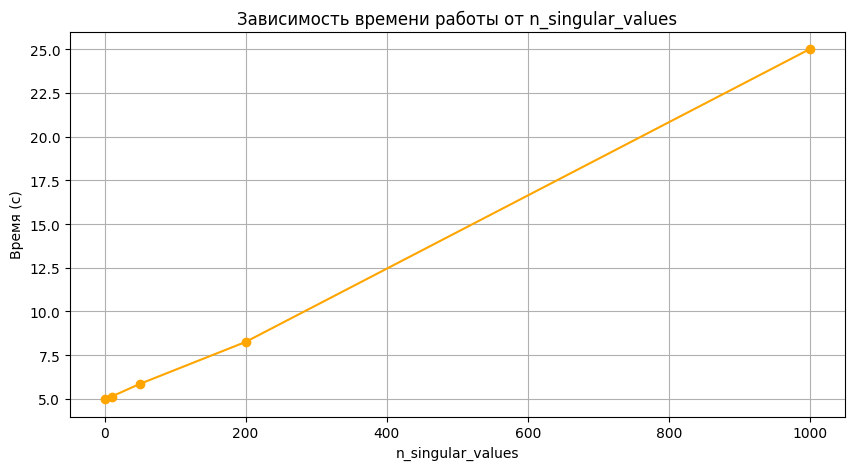

In [149]:
plot_graphs(coo_interactions, real_items_oreder)

##### Задание 3.1. Перейдем к [ALS](http://yifanhu.net/PUB/cf.pdf). Возьмем реализацию iALS из библиотеки [implicit](https://benfred.github.io/implicit/api/models/cpu/als.html). Обучите ALS на нашем датасете, сделайте top_k рекомендации для юзеров из тестового датасета, и сравните метрики ALS с метриками, которые получились в SVD. Попробуйте перебрать гиперпараметры и найдите оптимальное число факторов, коэффициент alpha и коэффициент регуляризации.

In [79]:
!pip3 install implicit

5073.29s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-macosx_14_0_arm64.whl size=751002 sha256=7038a7f0268f6e6bc94711cf0a8e5bc09c7f1dfe12b2889202cdb2e48475afe0
  Stored in directory: /Users/luka.markov/Library/Caches/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [115]:
import implicit
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix

def make_als_recommendations(
    interractions: Union[np.ndarray, coo_array], 
    top_k: int = 100, 
    n_factors: int = 100,
    alpha: float = 1.0,
    regularization: float = 0.01,
):

    if isinstance(interractions, coo_array):
        interractions = interractions.tocsr()
    else:
        interractions = csr_matrix(interractions)

    # Создаем и обучаем модель ALS
    model = AlternatingLeastSquares(iterations=10, factors=n_factors, regularization=regularization, calculate_training_loss=True)
    model.fit(interractions)

    n = train_users.max() + 1
    recommendations = np.full((n, top_k), -1, dtype=int)

    for user in np.unique(train_users):
        ids, scores = model.recommend(user, interractions[user], N=top_k)
        if len(ids) < top_k:
            ids = np.pad(ids, (0, top_k - len(ids)), constant_values=-1)
        recommendations[user] = ids
    
    return recommendations

In [116]:
recs = make_als_recommendations(interractions)
assert recs.shape == (interractions.shape[0], 100)

100%|██████████| 10/10 [00:02<00:00,  3.69it/s, loss=0.0298]


##### Задание 3.2. Сделайте объяснение рекомендаций для нескольких юзеров(als.explain). Воспользуйтесь файлом movies.dat чтобы перейти от индексов фильмов к их названием

In [ ]:
#your code here

##### Задание 4. До этого мы работали с рейтингами, но как обсуждалось на лекции, implicit ALS отлично работает и с implicit фидбэком. Давайте попробуем преобразовать наш датасет(трейн и тест) следующим образом

1. Бинаризуем все рейтинги(заменим любую интеракцию пользователя на 1)
2. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0
3. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1
4. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени. То есть чем дальше была интеракция от максимальной даты трейна, тем с меньшим весом мы будем ее учитывать(например можно интеракции за последний месяц брать в исходном виде, и с каждым месяцем в прошлое умножать их на какой-нибудь коэффициент меньший 1). Таким образом более старые интеракции пользователя будут вносить меньший вклад в его интересы
5. Придумайте свой вариант(опционально)

Для каждой полученной матрицы обучите iALS и SVD и сравните их результаты между собой(преобразовывать нужно только обучающую выборку, тестовую оставляем неизменной)

In [ ]:
#your code here

##### Задание 5. iALS на numpy/torch. Давайте реализуем алгоритм iALS на нумпае или торче. Требуется реализовать алгорит, описанный в 4 части [статьи](http://yifanhu.net/PUB/cf.pdf). Обратите внимания на все оптимизации, которые они описывают в статье, чтобы сократить лишние вычисления. Hint: метрики у вашего алгоритма должны быть сравнимы с метриками ALS из библиотеки implicit

In [ ]:
class iALS:
    def __init__(self, n_factors: int = 100, alpha: float = 1.0, reg_coef = 0.01):
        #your code here

    def fit(self, interractions: np.ndarray, n_iterations: int 10):
        #your code here

    def predict(self, top_k: int = 100):
        # возвращает top-k айтемов для каждого юзера(айтемы с которыми юзер взаимодействовал не должны попасть в рекомендации)
        #your code here

        return predicts # shape ~ [n_users, top_k]